In [1]:

import pandas as pd
import numpy as np

In [2]:
def process_nhanes_cycle(path_dict, cycle_name):

    demo = pd.read_sas(path_dict["DEMO"])
    dpq  = pd.read_sas(path_dict["DPQ"])
    bmx  = pd.read_sas(path_dict["BMX"])
    glu  = pd.read_sas(path_dict["GLU"])
    cbc  = pd.read_sas(path_dict["CBC"])

    if "CRP" in path_dict:
        crp_df = pd.read_sas(path_dict["CRP"])
    elif "BIOPRO" in path_dict:
        crp_df = pd.read_sas(path_dict["BIOPRO"])
    else:
        raise ValueError("Provide either 'CRP' or 'BIOPRO' in path_dict")

    df = demo.copy()
    df = df.merge(dpq,    on="SEQN", how="left")
    df = df.merge(bmx,    on="SEQN", how="left")
    df = df.merge(crp_df, on="SEQN", how="left")
    df = df.merge(glu,    on="SEQN", how="left")
    df = df.merge(cbc,    on="SEQN", how="left")

    df.replace([7, 77, 777, 9, 99, 999], np.nan, inplace=True)

    phq_cols = ["DPQ010","DPQ020","DPQ030","DPQ040","DPQ050",
                "DPQ060","DPQ070","DPQ080","DPQ090"]
    existing_phq = [c for c in phq_cols if c in df.columns]
    df["phq9_score"] = df[existing_phq].sum(axis=1)

    df["depression_label"] = (df["phq9_score"] >= 10).astype(int)

    df["suicide_q9"] = df["DPQ090"] if "DPQ090" in df.columns else np.nan

    crp_source_col = None
    for c in ["LBXCRP", "LBXSCRP", "URXCRP", "LBXHSCRP"]:
        if c in df.columns:
            crp_source_col = c
            break

    rename_map = {
        "RIDAGEYR": "age",
        "RIAGENDR": "sex",
        "RIDRETH1": "race",
        "DMDEDUC2": "education",
        "DMDMARTL": "marital_status",
        "INDFMPIR": "income_ratio",
        "BMXWT":   "weight",
        "BMXHT":   "height",
        "BMXBMI":  "bmi",
        "BMXWAIST":"waist",
        "BMXHIP":  "hip",
        "LBXGLU":  "glucose",
        "LBXWBCSI":"wbc",
        "LBXHGB":  "hemoglobin",
        "LBXPLTSI":"platelet"
    }
    if crp_source_col is not None:
        rename_map[crp_source_col] = "crp"

    df = df.rename(columns=rename_map)

    if "waist" in df.columns and "hip" in df.columns:
        df["waist_hip_ratio"] = df["waist"] / df["hip"]

    keep_cols = [
        "SEQN",
        "WTMEC2YR",
        "SDMVSTRA",
        "SDMVPSU",
        "age","sex","race","education","marital_status","income_ratio",
        "weight","height","bmi","waist","hip","waist_hip_ratio",
        "glucose","crp","wbc","hemoglobin","platelet",
        "phq9_score","depression_label","suicide_q9"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols]

    protected = {"SEQN","WTMEC2YR","SDMVSTRA","SDMVPSU",
                 "phq9_score","depression_label"}
    cols_to_check = [c for c in df.columns if c not in protected]
    good_cols     = [c for c in cols_to_check if df[c].isna().mean() < 0.5]
    df = df[list(protected.intersection(df.columns)) + good_cols]

    df = df.dropna(subset=["phq9_score"])

    df["cycle"] = cycle_name

    print(f"{cycle_name} → shape: {df.shape}")
    return df

In [3]:

# STEP 2: FILE PATHS FOR ALL CYCLES
#
# For each cycle just change the letter (D, E, F, G...)
# Use "CRP" key for 2005-2010
# Use "BIOPRO" key for 2011 onwards
#
# Make sure all files are uploaded to Colab before running

# --- 2005–2006 (letter D) ---
paths_2005 = {
    "DEMO": "DEMO_D.xpt",
    "DPQ":  "DPQ_D.xpt",
    "BMX":  "BMX_D.xpt",
    "CRP":  "CRP_D.xpt",
    "GLU":  "GLU_D.xpt",
    "CBC":  "CBC_D.xpt"
}

# --- 2007–2008 (letter E) ---
paths_2007 = {
    "DEMO": "DEMO_E.xpt",
    "DPQ":  "DPQ_E.xpt",
    "BMX":  "BMX_E.xpt",
    "CRP":  "CRP_E.xpt",
    "GLU":  "GLU_E.xpt",
    "CBC":  "CBC_E.xpt"
}

# --- 2009–2010 (letter F) ---
paths_2009 = {
    "DEMO": "DEMO_F.xpt",
    "DPQ":  "DPQ_F.xpt",
    "BMX":  "BMX_F.xpt",
    "CRP":  "CRP_F.xpt",
    "GLU":  "GLU_F.xpt",
    "CBC":  "CBC_F.xpt"
}

# --- 2011–2012 (letter G) --- CRP is inside BIOPRO
paths_2011 = {
    "DEMO":   "DEMO_G.xpt",
    "DPQ":    "DPQ_G.xpt",
    "BMX":    "BMX_G.xpt",
    "GLU":    "GLU_G.xpt",
    "CBC":    "CBC_G.xpt",
    "BIOPRO": "BIOPRO_G.xpt"
}

# --- 2013–2014 (letter H) --- CRP is inside BIOPRO
paths_2013 = {
    "DEMO":   "DEMO_H.xpt",
    "DPQ":    "DPQ_H.xpt",
    "BMX":    "BMX_H.xpt",
    "GLU":    "GLU_H.xpt",
    "CBC":    "CBC_H.xpt",
    "BIOPRO": "BIOPRO_H.xpt"
}

# --- 2015–2016 (letter I) --- CRP is inside BIOPRO
paths_2015 = {
    "DEMO":   "DEMO_I.xpt",
    "DPQ":    "DPQ_I.xpt",
    "BMX":    "BMX_I.xpt",
    "GLU":    "GLU_I.xpt",
    "CBC":    "CBC_I.xpt",
    "BIOPRO": "BIOPRO_I.xpt"
}

# --- 2017–2018 (letter J) --- CRP is inside BIOPRO
paths_2017 = {
    "DEMO":   "DEMO_J.xpt",
    "DPQ":    "DPQ_J.xpt",
    "BMX":    "BMX_J.xpt",
    "GLU":    "GLU_J.xpt",
    "CBC":    "CBC_J.xpt",
    "BIOPRO": "BIOPRO_J.xpt"
}

# --- 2019–2020 (letter K) --- COVID disrupted this cycle
# data is limited but still usable
paths_2019 = {
    "DEMO":   "DEMO_P.xpt",
    "DPQ":    "DPQ_P.xpt",
    "BMX":    "BMX_P.xpt",
    "GLU":    "GLU_P.xpt",
    "CBC":    "CBC_P.xpt",
    "BIOPRO": "BIOPRO_P.xpt"
}

# --- 2021–2023 (letter L) --- most recent available
paths_2021 = {
    "DEMO":   "DEMO_L.xpt",
    "DPQ":    "DPQ_L.xpt",
    "BMX":    "BMX_L.xpt",
    "GLU":    "GLU_L.xpt",
    "CBC":    "CBC_L.xpt",
    "BIOPRO": "BIOPRO_L.xpt"
}

In [4]:
# STEP 3: PROCESS EACH CYCLE
#
# If you do not have all files yet, comment out (#)
# the cycles you have not downloaded yet.
# Add them one by one as you download them.


df_2005 = process_nhanes_cycle(paths_2005, "2005_2006")
df_2007 = process_nhanes_cycle(paths_2007, "2007_2008")
df_2009 = process_nhanes_cycle(paths_2009, "2009_2010")
df_2011 = process_nhanes_cycle(paths_2011, "2011_2012")
df_2013 = process_nhanes_cycle(paths_2013, "2013_2014")
df_2015 = process_nhanes_cycle(paths_2015, "2015_2016")
df_2017 = process_nhanes_cycle(paths_2017, "2017_2018")
df_2019 = process_nhanes_cycle(paths_2019, "2019_2020")
df_2021 = process_nhanes_cycle(paths_2021, "2021_2023")

2005_2006 → shape: (10348, 20)
2007_2008 → shape: (10149, 22)
2009_2010 → shape: (10537, 22)
2011_2012 → shape: (9756, 21)
2013_2014 → shape: (10175, 21)
2015_2016 → shape: (9971, 21)
2017_2018 → shape: (9254, 23)
2019_2020 → shape: (15560, 21)
2021_2023 → shape: (11933, 21)


In [5]:

# STEP 4: COMBINE ALL CYCLES INTO ONE DATASET

final_df = pd.concat([
    df_2005,
    df_2007,
    df_2009,
    df_2011,
    df_2013,
    df_2015,
    df_2017,
    df_2019,
    df_2021
], ignore_index=True)

print("\n===== COMBINED DATASET =====")
print("Total rows:", final_df.shape[0])
print("Total columns:", final_df.shape[1])
print("\nRows per cycle:")
print(final_df["cycle"].value_counts().sort_index())


===== COMBINED DATASET =====
Total rows: 97683
Total columns: 24

Rows per cycle:
cycle
2005_2006    10348
2007_2008    10149
2009_2010    10537
2011_2012     9756
2013_2014    10175
2015_2016     9971
2017_2018     9254
2019_2020    15560
2021_2023    11933
Name: count, dtype: int64


In [6]:
# STEP 5: APPLY PROFESSOR'S WEIGHT CALCULATIONS
#
# Number of cycles = 9 (2005 to 2021)
# Update this number if you use fewer cycles

n_cycles = 9  # change this if you add or remove cycles

# Step 5a: Adjusted survey weight
final_df["weight_adj"] = final_df["WTMEC2YR"] / n_cycles

# Step 5b: Class weights using professor's exact formula
total_n     = len(final_df)
n_depressed = final_df["depression_label"].sum()
n_not_dep   = total_n - n_depressed

print(f"\nTotal N:       {total_n}")
print(f"Depressed:     {n_depressed}  ({100*n_depressed/total_n:.1f}%)")
print(f"Not depressed: {n_not_dep}  ({100*n_not_dep/total_n:.1f}%)")

final_df["class_weight"] = final_df["depression_label"].apply(
    lambda x: total_n / (2 * n_depressed) if x == 1
              else total_n / (2 * n_not_dep)
)

# Step 5c: Combined weight = adjusted survey weight x class weight
final_df["combined_weight"] = final_df["weight_adj"] * final_df["class_weight"]




Total N:       97683
Depressed:     4707  (4.8%)
Not depressed: 92976  (95.2%)


In [7]:
# STEP 6: SANITY CHECKS

print("\n--- Missing values (%) ---")
print((final_df.isna().mean() * 100).round(1).sort_values(ascending=False))

print("\n--- Survey design columns present? ---")
for col in ["WTMEC2YR", "SDMVSTRA", "SDMVPSU", "combined_weight"]:
    present = col in final_df.columns
    print(f"  {col}: {'YES' if present else 'MISSING'}")

print("\n--- Depression rate by sex ---")
print(final_df.groupby("sex")["depression_label"].mean().round(4))



--- Missing values (%) ---
waist_hip_ratio     77.1
hip                 76.9
crp                 76.2
suicide_q9          59.2
marital_status      57.6
education           47.1
wbc                 22.6
hemoglobin          20.9
platelet            20.8
waist               18.8
WTMEC2YR            15.9
weight_adj          15.9
combined_weight     15.9
bmi                 14.8
height              14.7
income_ratio        10.8
weight               8.7
age                  4.6
SDMVSTRA             1.5
sex                  0.0
race                 0.0
depression_label     0.0
SDMVPSU              0.0
phq9_score           0.0
SEQN                 0.0
cycle                0.0
class_weight         0.0
dtype: float64

--- Survey design columns present? ---
  WTMEC2YR: YES
  SDMVSTRA: YES
  SDMVPSU: YES
  combined_weight: YES

--- Depression rate by sex ---
sex
1.0    0.0363
2.0    0.0597
Name: depression_label, dtype: float64


In [8]:
# STEP 7: EXPORT CSV FOR R

final_df.to_csv("nhanes_combined_final.csv", index=False)
print("\nCSV exported successfully!")
print("Columns:", list(final_df.columns))


CSV exported successfully!
Columns: ['phq9_score', 'SEQN', 'WTMEC2YR', 'depression_label', 'SDMVSTRA', 'SDMVPSU', 'age', 'sex', 'race', 'marital_status', 'income_ratio', 'weight', 'height', 'bmi', 'waist', 'crp', 'wbc', 'hemoglobin', 'platelet', 'cycle', 'education', 'suicide_q9', 'hip', 'waist_hip_ratio', 'weight_adj', 'class_weight', 'combined_weight']


In [9]:
# STEP 8: PREPARE DATA FOR MODELING
#
# We pick features that exist in the dataset and have
# low missing values. We fill remaining missing values
# with the median so the model does not crash.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Choose features — only use columns that actually exist
features = [col for col in [
    "age", "sex", "income_ratio", "bmi", "wbc"
] if col in final_df.columns]

print("\nFeatures used:", features)

# Fill missing values with median
X = final_df[features].fillna(final_df[features].median())
y = final_df["depression_label"]

# Split into training (80%) and testing (20%)
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")



Features used: ['age', 'sex', 'income_ratio', 'bmi', 'wbc']

Training samples: 78146
Testing samples:  19537


In [10]:
# STEP 9: MODEL 1 — STANDARD LOGISTIC REGRESSION (baseline)
#
# This is the basic model with no imbalance handling.
# Expected result: high accuracy but zero recall for depressed.
# This shows WHY we need balancing.


print("\n" + "="*50)
print("MODEL 1: Standard Logistic Regression (baseline)")
print("="*50)

model_std = LogisticRegression(max_iter=1000, random_state=42)
model_std.fit(X_train, y_train)
y_pred_std = model_std.predict(X_test)

print(confusion_matrix(y_test, y_pred_std))
print(classification_report(y_test, y_pred_std))


MODEL 1: Standard Logistic Regression (baseline)
[[18613     4]
 [  917     3]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     18617
           1       0.43      0.00      0.01       920

    accuracy                           0.95     19537
   macro avg       0.69      0.50      0.49     19537
weighted avg       0.93      0.95      0.93     19537



In [11]:
# STEP 10: MODEL 2 — BALANCED LOGISTIC REGRESSION (best model)
#
# class_weight="balanced" tells the model to treat depressed
# people as more important, compensating for the imbalance.
# This is our main model.

print("\n" + "="*50)
print("MODEL 2: Balanced Logistic Regression (main model)")
print("="*50)

model_bal = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model_bal.fit(X_train, y_train)
y_pred_bal = model_bal.predict(X_test)

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

# AUC score
y_probs_bal = model_bal.predict_proba(X_test)[:, 1]
auc_bal = roc_auc_score(y_test, y_probs_bal)
print(f"AUC: {auc_bal:.4f}")





MODEL 2: Balanced Logistic Regression (main model)
[[12597  6020]
 [  271   649]]
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     18617
           1       0.10      0.71      0.17       920

    accuracy                           0.68     19537
   macro avg       0.54      0.69      0.49     19537
weighted avg       0.94      0.68      0.77     19537

AUC: 0.7526


In [12]:
# STEP 11: MODEL 3 — RANDOM FOREST WITH SMOTE
#
# SMOTE = Synthetic Minority Oversampling Technique
# It creates fake depressed samples to balance the dataset.
# Random Forest = a collection of many decision trees.
# Together they can handle imbalance better.

print("\n" + "="*50)
print("MODEL 3: Random Forest + SMOTE")
print("="*50)

# Apply SMOTE to training data only (never on test data)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — training samples: {len(X_train_sm)}")
print(f"Depressed in training: {y_train_sm.sum()}")

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# AUC for Random Forest
y_probs_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_probs_rf)
print(f"AUC: {auc_rf:.4f}")


MODEL 3: Random Forest + SMOTE
After SMOTE — training samples: 148718
Depressed in training: 74359
[[17772   845]
 [  637   283]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     18617
           1       0.25      0.31      0.28       920

    accuracy                           0.92     19537
   macro avg       0.61      0.63      0.62     19537
weighted avg       0.93      0.92      0.93     19537

AUC: 0.8256


In [13]:
# STEP 12: MODEL 3B — RANDOM FOREST WITH LOWER THRESHOLD
#
# By default the model uses 0.5 as threshold to decide
# depressed vs not. Lowering it to 0.3 means we flag more
# people as depressed — catching more real cases (higher recall)
# but also more false alarms (lower precision).

print("\n" + "="*50)
print("MODEL 3B: Random Forest + SMOTE + threshold 0.3")
print("="*50)

y_pred_rf_t = (y_probs_rf > 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_rf_t))
print(classification_report(y_test, y_pred_rf_t))


MODEL 3B: Random Forest + SMOTE + threshold 0.3
[[16442  2175]
 [  477   443]]
              precision    recall  f1-score   support

           0       0.97      0.88      0.93     18617
           1       0.17      0.48      0.25       920

    accuracy                           0.86     19537
   macro avg       0.57      0.68      0.59     19537
weighted avg       0.93      0.86      0.89     19537



In [14]:
# STEP 13: PHQ-9 REGRESSION MODEL
#
# Instead of predicting depressed vs not (classification),
# this model predicts the actual PHQ-9 score (0-27).
# Professor specifically mentioned this direction.
# MAE = Mean Absolute Error (lower is better)
# R2  = how much variation the model explains (higher is better)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("\n" + "="*50)
print("MODEL 4: PHQ-9 Score Regression")
print("="*50)

X_reg = final_df[features].fillna(final_df[features].median())
y_reg = final_df["phq9_score"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

print(f"MAE:  {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2:   {r2_score(y_test_r, y_pred_r):.4f}")


MODEL 4: PHQ-9 Score Regression
MAE:  2.0220
R2:   0.1214


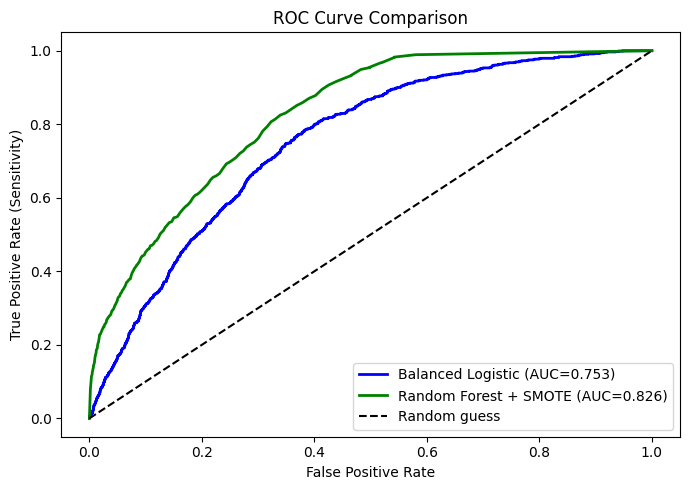

In [15]:
# STEP 14: ROC CURVE PLOT

# Shows how well the model separates depressed vs not.
# Blue = Balanced Logistic Regression
# Green = Random Forest + SMOTE
# Diagonal gray line = random guessing (useless model)
# Higher curve = better model

fpr_bal, tpr_bal, _ = roc_curve(y_test, y_probs_bal)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_bal, tpr_bal,
         label=f"Balanced Logistic (AUC={auc_bal:.3f})",
         color="blue", lw=2)
plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest + SMOTE (AUC={auc_rf:.3f})",
         color="green", lw=2)
plt.plot([0,1], [0,1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

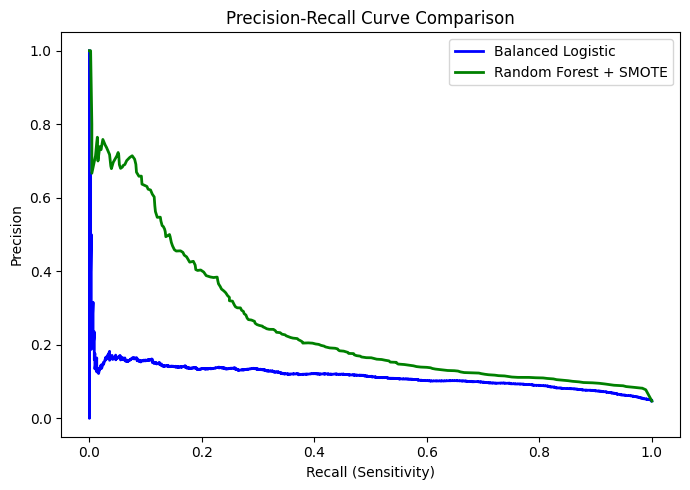

In [16]:
# STEP 15: PRECISION-RECALL CURVE
#
# More useful than ROC when data is imbalanced (like ours).
# Higher curve = model is better at finding depressed people
# without too many false alarms.

prec_bal, rec_bal, _ = precision_recall_curve(y_test, y_probs_bal)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(7, 5))
plt.plot(rec_bal, prec_bal, color="blue", lw=2,
         label="Balanced Logistic")
plt.plot(rec_rf,  prec_rf,  color="green", lw=2,
         label="Random Forest + SMOTE")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150)
plt.show()


--- Balanced Logistic Regression Coefficients ---
sex             0.425529
bmi             0.063780
wbc             0.059435
age             0.027296
income_ratio   -0.274214
dtype: float64

--- Random Forest Feature Importance ---
age             0.328929
bmi             0.211110
wbc             0.155867
income_ratio    0.155641
sex             0.148452
dtype: float64


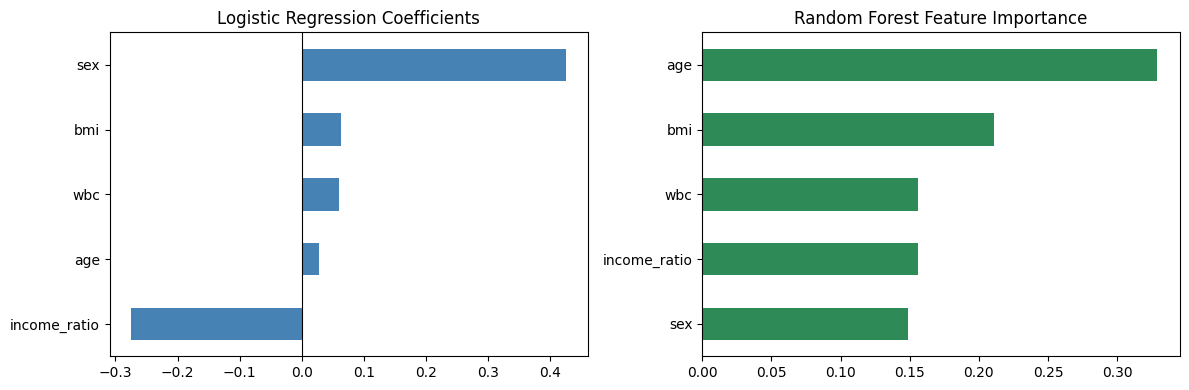

In [17]:
# STEP 16: FEATURE IMPORTANCE
# For Logistic Regression: coefficients tell us direction
#   Positive = increases depression risk
#   Negative = decreases depression risk
#
# For Random Forest: feature_importances_ tells us
#   which variables the model relied on most

print("\n--- Balanced Logistic Regression Coefficients ---")
coef_series = pd.Series(model_bal.coef_[0], index=features)
print(coef_series.sort_values(ascending=False))

print("\n--- Random Forest Feature Importance ---")
importance_series = pd.Series(rf.feature_importances_, index=features)
print(importance_series.sort_values(ascending=False))

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coef_series.sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Logistic Regression Coefficients")
axes[0].axvline(0, color="black", lw=0.8)

importance_series.sort_values().plot(
    kind="barh", ax=axes[1], color="seagreen"
)
axes[1].set_title("Random Forest Feature Importance")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [18]:
# STEP 17: FINAL SUMMARY TABLE

print("\n" + "="*55)
print("           FINAL MODEL COMPARISON SUMMARY")
print("="*55)
print(f"{'Model':<35} {'AUC':>6}  {'Note'}")
print("-"*55)
print(f"{'Standard Logistic Regression':<35} {'N/A':>6}  Failed (recall=0)")
print(f"{'Balanced Logistic Regression':<35} {auc_bal:>6.3f}  Best recall")
print(f"{'Random Forest + SMOTE':<35} {auc_rf:>6.3f}  Compare with logistic")
print(f"{'PHQ-9 Regression (MAE)':<35} {mean_absolute_error(y_test_r, y_pred_r):>6.3f}  Score prediction")
print("="*55)
print("\nNote: Final survey-weighted model should be run in R")
print("using svyglm() with the exported CSV file.")


           FINAL MODEL COMPARISON SUMMARY
Model                                  AUC  Note
-------------------------------------------------------
Standard Logistic Regression           N/A  Failed (recall=0)
Balanced Logistic Regression         0.753  Best recall
Random Forest + SMOTE                0.826  Compare with logistic
PHQ-9 Regression (MAE)               2.022  Score prediction

Note: Final survey-weighted model should be run in R
using svyglm() with the exported CSV file.
